# Kaggle Indian Personal Finance EDA & Cashflow Prediction

This notebook loads the `shriyashjagtap/indian-personal-finance-and-spending-habits` dataset using `kagglehub`.
Since this dataset contains cross-sectional monthly snapshots for 20,000 individuals, we will synthesize `user_id` and `period` (date) columns so that we can run it through our time-series `CashflowForecaster` (Prophet + LightGBM).


In [1]:
import os
import warnings
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

# Add src to Python path so we can import our pipeline components
src_path = Path(os.getcwd()).parent / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from forecaster import CashflowForecaster
from forecaster import CashflowForecaster
from ml_trainer import tune_cashflow_forecaster, run_training_experiment

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="muted")


## 1. Load Dataset

In [2]:
print("Downloading dataset...")
path = kagglehub.dataset_download("shriyashjagtap/indian-personal-finance-and-spending-habits")
print("Path to dataset files:", path)

# Find the csv file
csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

if not csv_file:
    raise FileNotFoundError("Could not find CSV file in downloaded Kaggle dataset.")

df = pd.read_csv(csv_file)
print(f"Dataset loaded with {len(df)} rows.")

df.head()


Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\shriyashjagtap\indian-personal-finance-and-spending-habits\versions\1
Dataset loaded with 20000 rows.


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


## 2. Synthesize Time Series Features
The dataset lacks `user_id` and `date`. To use our time-series `CashflowForecaster`, we will group the 20,000 rows into 500 "users", each with 40 months of data.


In [3]:
num_users = 500
records_per_user = len(df) // num_users

# Create date range of 40 months starting from 2020-01-01
dates = pd.date_range(start="2020-01-01", periods=records_per_user, freq='MS')

# Assign user_ids and dates
df['user_id'] = np.repeat(np.arange(num_users), records_per_user)
df['date'] = np.tile(dates, num_users)

df = df.sort_values(['user_id', 'date']).reset_index(drop=True)
df.head()


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,user_id,date
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517,0,2020-01-01
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606,0,2020-02-01
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422,0,2020-03-01
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183,0,2020-04-01
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076,0,2020-05-01


## 3. Map Schema to Pipeline
We will map the existing financial columns to the schema expected by our pipeline: `period`, `total_inflow`, `total_outflow`, `net_cashflow`, etc.


In [4]:
def map_to_pipeline_schema(df: pd.DataFrame) -> pd.DataFrame:
    mapped = df.copy()
    
    # Map core expected features
    mapped = mapped.rename(columns={
        "date": "period",
        "Income": "total_inflow",
        "Rent": "rent_amount",
        "Loan_Repayment": "emi_amount"
    })
    
    # Calculate total outflow
    expense_cols = ['rent_amount', 'emi_amount', 'Insurance', 'Groceries', 
                    'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 
                    'Healthcare', 'Education', 'Miscellaneous']
    
    mapped['total_outflow'] = mapped[expense_cols].sum(axis=1)
    
    # Calculate net cashflow
    mapped["net_cashflow"] = mapped["total_inflow"] - mapped["total_outflow"]
    
    # Calculate fixed obligation ratio
    mapped["fixed_obligations"] = mapped["emi_amount"] + mapped["rent_amount"]
    mapped["fixed_obligation_ratio"] = mapped["fixed_obligations"] / mapped["total_inflow"]
    
    # Calculate discretionary spending
    discretionary_cols = ['Eating_Out', 'Entertainment', 'Miscellaneous']
    mapped['discretionary_amount'] = mapped[discretionary_cols].sum(axis=1)
    
    # ── ADVANCED FEATURE ENGINEERING ──
    # 1. Savings Rate
    mapped['savings_rate'] = mapped['net_cashflow'] / mapped['total_inflow']
    
    # 2. Debt-to-Income Ratio
    mapped['debt_to_income_ratio'] = mapped['emi_amount'] / mapped['total_inflow']
    
    # 3. Discretionary Spending Ratio
    mapped['discretionary_ratio'] = mapped['discretionary_amount'] / mapped['total_inflow']
    
    # 4. Desired Savings Gap
    # If gap is positive, the person didn't reach their desired savings.
    mapped['desired_savings_gap'] = mapped['Desired_Savings'] - mapped['net_cashflow']
    
    # 5. Total Potential Savings
    potential_savings_cols = [c for c in mapped.columns if 'Potential_Savings' in c]
    mapped['total_potential_savings'] = mapped[potential_savings_cols].sum(axis=1)
    
    # 6. Optimized Cashflow (if they realized all potential savings)
    mapped['optimized_net_cashflow'] = mapped['net_cashflow'] + mapped['total_potential_savings']
    
    # 7. Age Decades
    mapped['age_decade'] = (mapped['Age'] // 10) * 10

    return mapped

mapped_df = map_to_pipeline_schema(df)
print("Engineered Features:")
print(mapped_df[['savings_rate', 'debt_to_income_ratio', 'discretionary_ratio', 'desired_savings_gap', 'total_potential_savings', 'optimized_net_cashflow']].head())
mapped_df.head()


Engineered Features:
   savings_rate  debt_to_income_ratio  discretionary_ratio  \
0      0.252382              0.000000             0.090048   
1      0.360288              0.000000             0.084288   
2      0.275801              0.091569             0.076746   
3      0.311643              0.067117             0.102749   
4      0.251885              0.125129             0.075116   

   desired_savings_gap  total_potential_savings  optimized_net_cashflow  
0         -5065.090514              3507.222841            14772.850548  
1         -7753.642299              1482.618056            11159.436789  
2         -6841.090203              3551.316456            17442.767081  
3        -14922.988478              6078.520570            37696.474185  
4         -4391.601098              1511.357063             7777.057595  


,total_inflow,Age,Dependents,Occupation,City_Tier,rent_amount,emi_amount,Insurance,Groceries,Transport,...,fixed_obligations,fixed_obligation_ratio,discretionary_amount,savings_rate,debt_to_income_ratio,discretionary_ratio,desired_savings_gap,total_potential_savings,optimized_net_cashflow,age_decade
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,13391.174891,0.300000,4019.511102,0.252382,0.000000,0.090048,-5065.090514,3507.222841,14772.850548,40
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,5371.719318,0.200000,2263.854847,0.360288,0.000000,0.084288,-7753.642299,1482.618056,11159.436789,30
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,12167.244149,0.241569,3865.492522,0.275801,0.091569,0.076746,-6841.090203,3551.316456,17442.767081,30
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,22027.781464,0.217117,10424.499110,0.311643,0.067117,0.102749,-14922.988478,6078.520570,37696.474185,20
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,8087.666108,0.325129,1868.524377,0.251885,0.125129,0.075116,-4391.601098,1511.357063,7777.057595,50


## 4. Exploratory Data Analysis (EDA)
Let's explore the distribution of Income vs Rent, and how Potential Savings vary by Occupation.


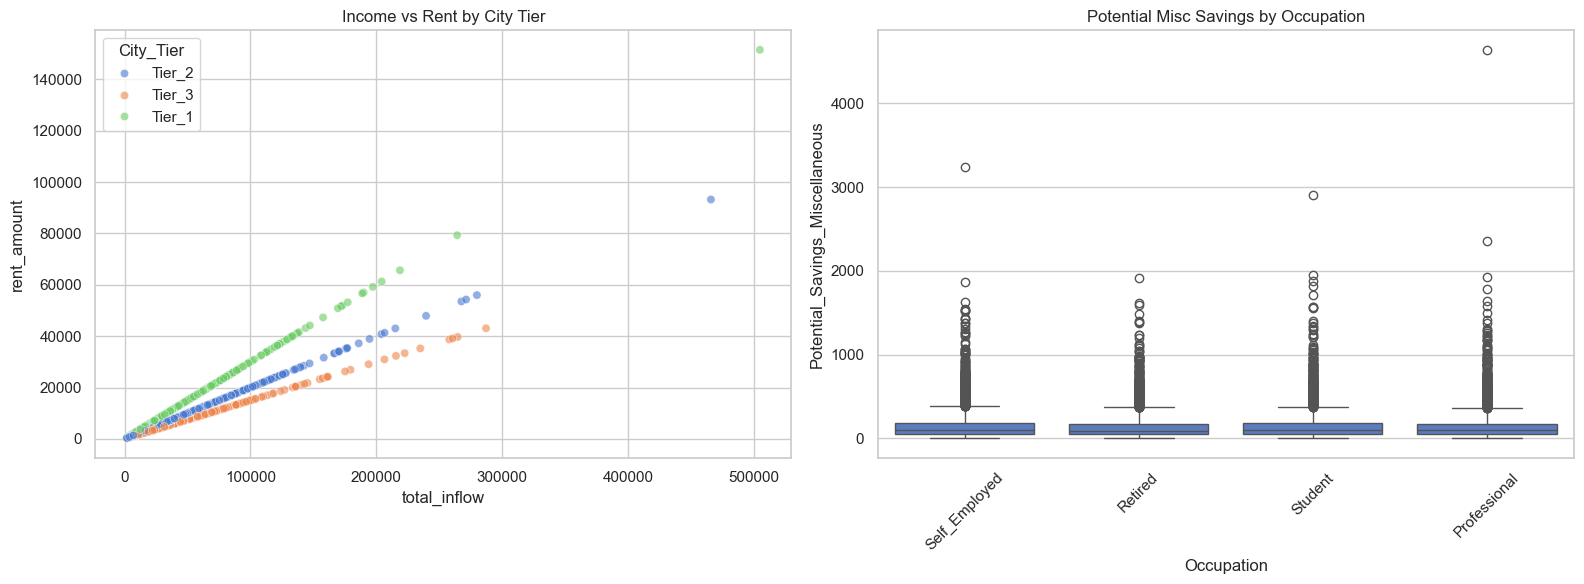

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=mapped_df.sample(2000), x='total_inflow', y='rent_amount', hue='City_Tier', alpha=0.6, ax=axes[0])
axes[0].set_title('Income vs Rent by City Tier')

# Potential savings by occupation
sns.boxplot(data=mapped_df, x='Occupation', y='Potential_Savings_Miscellaneous', ax=axes[1])
axes[1].set_title('Potential Misc Savings by Occupation')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 5. Model Tuning (Optuna)
We will extract the time-series for a target user and tune the LightGBM hyperparameters using Optuna (logged to MLflow).


In [6]:
target_user = 0
user_df = mapped_df[mapped_df['user_id'] == target_user].copy()
user_df = user_df.sort_values('period')

print(f"Running Optuna tuning for User {target_user}...")
best_params = tune_cashflow_forecaster(
    df=user_df, 
    n_trials=10, 
    run_name=f"kaggle_indian_{target_user}_tuning"
)
print("\nTuning Complete! Best LightGBM Parameters found:")
print(best_params)


Running Optuna tuning for User 0...



[OPTUNA] Starting 5-Fold Walk-Forward CV Search | 3 trials remaining...


14:28:25 - cmdstanpy - INFO - Chain [1] start processing


14:28:25 - cmdstanpy - INFO - Chain [1] done processing


14:28:27 - cmdstanpy - INFO - Chain [1] start processing


14:28:27 - cmdstanpy - INFO - Chain [1] done processing


14:28:28 - cmdstanpy - INFO - Chain [1] start processing


14:28:29 - cmdstanpy - INFO - Chain [1] done processing


[OPTUNA] Best trial #2 — Mean CV RMSE: 11,861

Tuning Complete! Best LightGBM Parameters found:
{'learning_rate': 0.012258167424636266, 'num_leaves': 24, 'max_depth': 6, 'min_child_samples': 4, 'subsample': 0.9229310367578227, 'colsample_bytree': 0.7228025938382423, 'reg_alpha': 0.005571833402930394, 'reg_lambda': 0.001421009521028895, 'n_estimators': 500, 'random_state': 42, 'n_jobs': -1}


## 6. Full Training Experiment & Metrics (MLflow)
Now we'll run the full platform training pipeline (Train/Val/Test splits + SHAP) and explicitly print the test metrics.


In [7]:
# Run Full Training Experiment (Train/Val/Test + SHAP + MLflow)
print("\nRunning Full Training Experiment...")
report = run_training_experiment(
    entity_id=target_user,
    features_df=user_df,
    lgbm_params=best_params
)

print("\n=== Train Set Evaluation Metrics ===")
print(f"RMSE: {report.train_metrics.get('rmse', 0):.2f}")
print(f"MAE:  {report.train_metrics.get('mae', 0):.2f}")
print(f"MAPE: {report.train_metrics.get('mape', 0):.2f}%")
print(f"R2:   {report.train_metrics.get('r2', 0):.4f}")

print("\n=== Test Set Evaluation Metrics ===")
print(f"RMSE: {report.test_metrics.get('rmse', 0):.2f}")
print(f"MAE:  {report.test_metrics.get('mae', 0):.2f}")
print(f"MAPE: {report.test_metrics.get('mape', 0):.2f}%")
print(f"R2:   {report.test_metrics.get('r2', 0):.4f}")

# Extract final forecaster for predictions
import joblib
from pathlib import Path
model_path = Path("models") / f"forecaster_{target_user}.joblib"
forecaster = joblib.load(model_path)



Running Full Training Experiment...
  CASHFLOW TRAINING EXPERIMENT — Entity: 0
  Split: train=28m  val=6m  test=6m

  ── Walk-Forward CV (3 folds) ──


14:28:29 - cmdstanpy - INFO - Chain [1] start processing


14:28:29 - cmdstanpy - INFO - Chain [1] done processing


  CV Fold 1: MAPE=75.2%  RMSE=10,519  MAE=8,631  R²=-3.364  CI%=33.3%


14:28:30 - cmdstanpy - INFO - Chain [1] start processing


...

14:28:33 - cmdstanpy - INFO - Chain [1] done processing


14:28:34 - cmdstanpy - INFO - Chain [1] start processing


14:28:34 - cmdstanpy - INFO - Chain [1] done processing



  ── Computing SHAP Importances ──



  MLflow Run ID: 8c4d9dbd6eb84d1d9ec99b00dca85ba1

════════════════════════════════════════════════════════════
  CASHFLOW FORECASTER — TRAINING REPORT
════════════════════════════════════════════════════════════
  MLflow Run ID : 8c4d9dbd6eb84d1d9ec99b00dca85ba1
  Train months  : 28
  Val months    : 6
  Test months   : 6

  ── Metrics by Split ──
  Train  | MAPE=  75.9%  RMSE=     4,152  MAE=     3,053  R²=+0.796  CI%=85.7%
  Val    | MAPE= 217.3%  RMSE=    20,407  MAE=    15,064  R²=-0.424  CI%=33.3%
  Test   | MAPE= 183.9%  RMSE=     6,306  MAE=     4,784  R²=-0.095  CI%=83.3%
  CV Avg | MAPE= 318.0%  RMSE=    21,574  MAE=    17,908  R²=-46.652  CI%=11.1%
════════════════════════════════════════════════════════════

=== Train Set Evaluation Metrics ===
RMSE: 4151.98
MAE:  3052.98
MAPE: 75.95%
R2:   0.7959

=== Test Set Evaluation Metrics ===
RMSE: 6305.70
MAE:  4784.28
MAPE: 183.90%
R2:   -0.0947


## 7. Predict the Next 12 Months
Let's forecast cashflow for the next 3, 6, 9, and 12 months for this user.


In [8]:
from IPython.display import display
horizons = [3, 6, 9, 12]
forecasts = {}

for h in horizons:
    print(f"--- Forecasting {h} months ahead ---")
    forecast_df = forecaster.predict(horizon=h)
    forecasts[h] = forecast_df
    display(forecast_df.head(h))
    print("\n")


--- Forecasting 3 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2022-05-01,7945.855260,2631.315056,13260.395464,6163.191221,9728.519298
1,2022-06-01,16144.098010,10829.557806,21458.638214,22559.676721,9728.519298
2,2022-07-01,-9247.063667,-14561.603871,-3932.523464,-28222.646633,9728.519298




--- Forecasting 6 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2022-05-01,7945.855260,2631.315056,13260.395464,6163.191221,9728.519298
1,2022-06-01,16144.098010,10829.557806,21458.638214,22559.676721,9728.519298
2,2022-07-01,-9247.063667,-14561.603871,-3932.523464,-28222.646633,9728.519298
3,2022-08-01,6262.871978,948.331774,11577.412182,2797.224658,9728.519298
4,2022-09-01,24653.733689,19339.193485,29968.273893,39578.948079,9728.519298
5,2022-10-01,-312.816678,-5627.356882,5001.723526,-10354.152655,9728.519298




--- Forecasting 9 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2022-05-01,7945.855260,2631.315056,13260.395464,6163.191221,9728.519298
1,2022-06-01,16144.098010,10829.557806,21458.638214,22559.676721,9728.519298
2,2022-07-01,-9247.063667,-14561.603871,-3932.523464,-28222.646633,9728.519298
3,2022-08-01,6262.871978,948.331774,11577.412182,2797.224658,9728.519298
4,2022-09-01,24653.733689,19339.193485,29968.273893,39578.948079,9728.519298
5,2022-10-01,-312.816678,-5627.356882,5001.723526,-10354.152655,9728.519298
6,2022-11-01,6239.294954,924.754750,11553.835157,2750.070609,9728.519298
7,2022-12-01,1573.936811,-3740.603393,6888.477014,-6580.645677,9728.519298
8,2023-01-01,3814.470363,-1500.069841,9129.010566,-2099.578573,9728.519298




--- Forecasting 12 months ahead ---


,period,forecast,lower_p10,upper_p90,prophet_forecast,lgbm_forecast
0,2022-05-01,7945.855260,2631.315056,13260.395464,6163.191221,9728.519298
1,2022-06-01,16144.098010,10829.557806,21458.638214,22559.676721,9728.519298
2,2022-07-01,-9247.063667,-14561.603871,-3932.523464,-28222.646633,9728.519298
3,2022-08-01,6262.871978,948.331774,11577.412182,2797.224658,9728.519298
4,2022-09-01,24653.733689,19339.193485,29968.273893,39578.948079,9728.519298
5,2022-10-01,-312.816678,-5627.356882,5001.723526,-10354.152655,9728.519298
6,2022-11-01,6239.294954,924.754750,11553.835157,2750.070609,9728.519298
7,2022-12-01,1573.936811,-3740.603393,6888.477014,-6580.645677,9728.519298
8,2023-01-01,3814.470363,-1500.069841,9129.010566,-2099.578573,9728.519298
9,2023-02-01,4548.118002,-766.422202,9862.658205,-632.283295,9728.519298
